# 04 GBDT baseline

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, log_loss, roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold

In [2]:
def load(part):
    transaction = pd.read_csv(f"../data/raw/{part}_transaction.csv")
    identity = pd.read_csv(f"../data/raw/{part}_identity.csv")
    identity.columns = identity.columns.str.replace("-", "_")
    df = transaction.merge(identity, on="TransactionID", how="left", indicator=True)
    df["has_identity"] = (df.pop("_merge") == "both").astype(int)
    floats = df.select_dtypes("float64").columns
    df[floats] = df[floats].astype(np.float32)
    return df


df = pd.concat([load("train"), load("test")], ignore_index=True)
is_test = df["isFraud"].isna().to_numpy()
train_idx = np.flatnonzero(~is_test)
test_idx = np.flatnonzero(is_test)
y = df.loc[train_idx, "isFraud"].astype(int).to_numpy()

print(df.shape, "train:", len(train_idx), "test:", len(test_idx))

(1097231, 435) train: 590540 test: 506691


## CV

In [3]:
blocks = pd.qcut(df.loc[train_idx, "TransactionDT"], 4, labels=False).to_numpy()
folds = [(np.flatnonzero(blocks != g), np.flatnonzero(blocks == g)) for g in range(4)]

PARAMS = {
    "objective": "binary", "learning_rate": 0.1, "num_leaves": 63, "min_child_samples": 100,
    "feature_fraction": 0.5, "bagging_fraction": 0.8, "bagging_freq": 1, "lambda_l2": 0.0,
    "max_bin": 63, "verbose": -1, "seed": 42,
}


def cv_lgb(cols, params):
    X_train = X.loc[train_idx, cols].to_numpy()
    oof = np.zeros(len(train_idx))
    aucs = []
    trees = []
    for tr, va in folds:
        n_es = len(tr) // 10
        fit, es = tr[:-n_es], tr[-n_es:]
        train_set = lgb.Dataset(X_train[fit], y[fit])
        valid_set = lgb.Dataset(X_train[es], y[es], reference=train_set)
        model = lgb.train(params, train_set, 3000, valid_sets=[valid_set],
                          callbacks=[lgb.early_stopping(100, verbose=False)])
        oof[va] = model.predict(X_train[va], num_iteration=model.best_iteration)
        aucs.append(roc_auc_score(y[va], oof[va]))
        trees.append(model.best_iteration)
    return np.array(aucs), trees, oof

## Features

In [4]:
day = df["TransactionDT"] // 86400
hour = df["TransactionDT"] // 3600 % 24
raw_features = [c for c in df.columns if c not in ["TransactionID", "TransactionDT", "isFraud", "has_identity"]]

basic = pd.DataFrame({
    "has_identity": df["has_identity"],
    "amt_cents": df["TransactionAmt"] % 1,
    "hour": hour,
    "hour_sin": np.sin(2 * np.pi * hour / 24),
    "hour_cos": np.cos(2 * np.pi * hour / 24),
    "nan_count": df[raw_features].isna().sum(axis=1),
})

In [5]:
freq_cols = ["card1", "card2", "card3", "card5", "addr1", "addr2",
             "P_emaildomain", "R_emaildomain", "DeviceInfo", "id_31"]

freq = pd.DataFrame()
for col in freq_cols:
    values = df[col].astype(str)
    freq[col + "_freq"] = values.map(values.value_counts())

In [6]:
def split_family_version(s):
    s = s.str.lower()
    version = pd.to_numeric(s.str.extract(r"(\d+(?:[._]\d+)?)")[0].str.replace("_", "."), errors="coerce")
    family = s.str.replace(r"\s*\d.*$", "", regex=True).str.strip()
    return family, version


browser_family, browser_version = split_family_version(df["id_31"])
os_family, os_version = split_family_version(df["id_30"])

parsed = pd.DataFrame({
    "browser_family": browser_family,
    "browser_version": browser_version,
    "os_family": os_family,
    "os_version": os_version,
})
parsed["browser_version_lag"] = parsed.groupby("browser_family")["browser_version"].cummax() - parsed["browser_version"]

print(df["id_31"].nunique(), "browser strings ->", browser_family.nunique(), "families")

172 browser strings -> 55 families


In [7]:
uid = df["card1"].astype(str) + "_" + df["addr1"].astype(str) + "_" + (day - df["D1"]).astype(str)

per_client = pd.Series(y).groupby(uid.iloc[train_idx].to_numpy()).agg(["mean", "size"])
multi = per_client[per_client["size"] > 1]

print("client keys:", uid.nunique(), "card1 values:", df["card1"].nunique())
print("train clients with >1 transaction:", len(multi))
print("test rows with a client seen in train:", uid.iloc[test_idx].isin(per_client.index).mean().round(3))
print("share with one label for all:", ((multi["mean"] == 0) | (multi["mean"] == 1)).mean())
print("share with some fraud:", (multi["mean"] > 0).mean())

client keys: 386568 card1 values: 17091
train clients with >1 transaction: 92628
test rows with a client seen in train: 0.226
share with one label for all: 0.9664032473981949
share with some fraud: 0.055080537202573734


97% of clients have the same label on all their transactions, so the label is basically per client.

In [8]:
grp = df.groupby(uid)
client = pd.DataFrame({
    "uid_count": grp["TransactionID"].transform("size"),
    "uid_amt_mean": grp["TransactionAmt"].transform("mean"),
    "uid_amt_std": grp["TransactionAmt"].transform("std"),
    "uid_D15_mean": grp["D15"].transform("mean"),
    "uid_C13_mean": grp["C13"].transform("mean"),
    "uid_dist1_mean": grp["dist1"].transform("mean"),
    "uid_email_nunique": grp["P_emaildomain"].transform("nunique"),
    "uid_device_nunique": grp["DeviceInfo"].transform("nunique"),
    "uid_days_active": (grp["TransactionDT"].transform("max") - grp["TransactionDT"].transform("min")) / 86400,
})
client["amt_to_uid_mean"] = df["TransactionAmt"] / client["uid_amt_mean"]

In [9]:
X = pd.concat([df[raw_features], basic, freq, parsed, client], axis=1)
for col in X.select_dtypes(exclude="number").columns:
    codes = pd.factorize(X[col])[0]
    X[col] = np.where(codes == -1, np.nan, codes)
X = X.astype(np.float32)

levels = {}
levels["raw"] = raw_features
levels["+ basic"] = levels["raw"] + list(basic.columns)
levels["+ frequency"] = levels["+ basic"] + list(freq.columns)
levels["+ browser/OS"] = [c for c in levels["+ frequency"] if c not in ["id_30", "id_31"]] + list(parsed.columns)
levels["+ client"] = levels["+ browser/OS"] + list(client.columns)

for name, cols in levels.items():
    print(name, len(cols))

raw 431
+ basic 437
+ frequency 447
+ browser/OS 450
+ client 460


## Feature blocks

In [10]:
fold_aucs = {}
for name, cols in levels.items():
    fold_aucs[name] = cv_lgb(cols, PARAMS)[0]
    print(name, fold_aucs[name].mean().round(4), fold_aucs[name].round(4))

ladder = pd.DataFrame({"CV AUC": {k: v.mean() for k, v in fold_aucs.items()}})
ladder["gain"] = ladder["CV AUC"].diff()
names = list(levels)
folds_better = [None]
for i in range(1, len(names)):
    folds_better.append((fold_aucs[names[i]] > fold_aucs[names[i - 1]]).sum())
ladder["folds better"] = folds_better
ladder.round(4)

raw 0.9109 [0.9107 0.9183 0.9245 0.89  ]


+ basic 0.915 [0.9121 0.9241 0.925  0.8987]


+ frequency 0.9178 [0.9148 0.9267 0.9275 0.9021]


+ browser/OS 0.9176 [0.9173 0.9224 0.9267 0.904 ]


+ client 0.9294 [0.9256 0.9407 0.9401 0.9114]


,CV AUC,gain,folds better
raw,0.9109,NaN,NaN
+ basic,0.9150,0.0041,4.0
+ frequency,0.9178,0.0028,4.0
+ browser/OS,0.9176,-0.0002,2.0
+ client,0.9294,0.0119,4.0


Client features give the biggest gain (+0.012).

## Drift check

In [11]:
rng = np.random.default_rng(42)
adv_train = np.sort(rng.choice(train_idx, size=120_000, replace=False))
adv_test = np.sort(rng.choice(test_idx, size=120_000, replace=False))
adv_idx = np.concatenate([adv_train, adv_test])
adv_y = np.concatenate([np.zeros(len(adv_train)), np.ones(len(adv_test))])

ADV_PARAMS = {
    "objective": "binary", "learning_rate": 0.1, "num_leaves": 31, "min_child_samples": 200,
    "feature_fraction": 0.5, "bagging_fraction": 0.8, "bagging_freq": 1, "max_bin": 63,
    "verbose": -1, "seed": 42,
}


def adversarial_auc(cols):
    X_adv = X.loc[adv_idx, cols].to_numpy()
    oof = np.zeros(len(adv_y))
    gain = np.zeros(len(cols))
    for tr, va in StratifiedKFold(3, shuffle=True, random_state=42).split(X_adv, adv_y):
        model = lgb.train(ADV_PARAMS, lgb.Dataset(X_adv[tr], adv_y[tr]), 150)
        oof[va] = model.predict(X_adv[va])
        gain += model.feature_importance("gain")
    return roc_auc_score(adv_y, oof), pd.Series(gain / gain.sum(), index=cols)


new_cols = [c for c in levels["+ client"] if c not in raw_features]
adv_raw = adversarial_auc(levels["raw"])[0]
adv_eng, adv_imp = adversarial_auc(levels["+ client"])

print("raw:", round(adv_raw, 4))
print("engineered:", round(adv_eng, 4))
print("gain share of new features:", round(adv_imp[new_cols].sum(), 3))
print(adv_imp[new_cols].sort_values(ascending=False).head(6).round(3))

raw: 0.9091
engineered: 0.9418
gain share of new features: 0.336
browser_version        0.101
uid_days_active        0.053
browser_version_lag    0.037
uid_D15_mean           0.034
nan_count              0.027
id_31_freq             0.021
dtype: float64


The new features increase the drift (0.909 to 0.942).

In [12]:
top3 = adv_imp[new_cols].sort_values(ascending=False).index[:3]
no_top3 = [c for c in levels["+ client"] if c not in top3]

aucs_no_top3 = cv_lgb(no_top3, PARAMS)[0]
adv_no_top3 = adversarial_auc(no_top3)[0]

print("dropped:", list(top3))
print("CV AUC:", round(fold_aucs["+ client"].mean(), 4), "->", round(aucs_no_top3.mean(), 4))
print("folds better:", (aucs_no_top3 > fold_aucs["+ client"]).sum())
print("adversarial AUC:", round(adv_eng, 4), "->", round(adv_no_top3, 4))

dropped: ['browser_version', 'uid_days_active', 'browser_version_lag']
CV AUC: 0.9294 -> 0.9281
folds better: 1
adversarial AUC: 0.9418 -> 0.9247


Dropping the three worst ones lowers the drift but also the CV, so I keep all features.

## Hyperparameter search

In [13]:
features = levels["+ client"]

space = {
    "num_leaves": [31, 63, 127, 255],
    "min_child_samples": [20, 50, 100, 200],
    "feature_fraction": [0.3, 0.5, 0.7],
    "bagging_fraction": [0.7, 0.9],
    "lambda_l2": [0.0, 1.0, 10.0],
}

search_rng = np.random.default_rng(42)
configs = [{k: PARAMS[k] for k in space}]
while len(configs) < 8:
    cfg = {k: v[search_rng.integers(len(v))] for k, v in space.items()}
    if cfg not in configs:
        configs.append(cfg)

rows = []
for cfg in configs:
    aucs, trees, _ = cv_lgb(features, {**PARAMS, **cfg})
    rows.append({**cfg, "CV AUC": aucs.mean(), "trees": int(np.median(trees))})
    print(cfg, round(aucs.mean(), 4))

tuning = pd.DataFrame(rows).sort_values("CV AUC", ascending=False)
tuning.round(4)

{'num_leaves': 63, 'min_child_samples': 100, 'feature_fraction': 0.5, 'bagging_fraction': 0.8, 'lambda_l2': 0.0} 0.9294


{'num_leaves': 31, 'min_child_samples': 200, 'feature_fraction': 0.5, 'bagging_fraction': 0.7, 'lambda_l2': 1.0} 0.9287


{'num_leaves': 255, 'min_child_samples': 20, 'feature_fraction': 0.7, 'bagging_fraction': 0.7, 'lambda_l2': 0.0} 0.9311


{'num_leaves': 127, 'min_child_samples': 200, 'feature_fraction': 0.7, 'bagging_fraction': 0.9, 'lambda_l2': 10.0} 0.9341


{'num_leaves': 255, 'min_child_samples': 100, 'feature_fraction': 0.3, 'bagging_fraction': 0.9, 'lambda_l2': 1.0} 0.932


{'num_leaves': 127, 'min_child_samples': 50, 'feature_fraction': 0.3, 'bagging_fraction': 0.9, 'lambda_l2': 10.0} 0.9314


{'num_leaves': 127, 'min_child_samples': 50, 'feature_fraction': 0.7, 'bagging_fraction': 0.9, 'lambda_l2': 1.0} 0.9329


{'num_leaves': 63, 'min_child_samples': 20, 'feature_fraction': 0.3, 'bagging_fraction': 0.9, 'lambda_l2': 10.0} 0.9312


,num_leaves,min_child_samples,feature_fraction,bagging_fraction,lambda_l2,CV AUC,trees
3,127,200,0.7,0.9,10.0,0.9341,241
6,127,50,0.7,0.9,1.0,0.9329,163
4,255,100,0.3,0.9,1.0,0.9320,117
5,127,50,0.3,0.9,10.0,0.9314,272
7,63,20,0.3,0.9,10.0,0.9312,485
2,255,20,0.7,0.7,0.0,0.9311,92
0,63,100,0.5,0.8,0.0,0.9294,364
1,31,200,0.5,0.7,1.0,0.9287,707


Tuning gives only +0.005, less than the features.

## Final models

In [14]:
best = tuning.iloc[0]
FINAL_PARAMS = {
    **PARAMS,
    "num_leaves": int(best["num_leaves"]),
    "min_child_samples": int(best["min_child_samples"]),
    "feature_fraction": best["feature_fraction"],
    "bagging_fraction": best["bagging_fraction"],
    "lambda_l2": best["lambda_l2"],
    "learning_rate": 0.05,
}

results = []
models = {}
oof_preds = {}
test_preds = {}

for name, cols, params in [("lgb_engineered", features, FINAL_PARAMS), ("lgb_raw", raw_features, PARAMS)]:
    aucs, trees, oof = cv_lgb(cols, params)
    n_trees = int(np.median(trees) * 1.1)
    model = lgb.train(params, lgb.Dataset(X.loc[train_idx, cols].to_numpy(), y), n_trees)
    models[name] = model
    oof_preds[name] = oof
    test_preds[name] = model.predict(X.loc[test_idx, cols].to_numpy())
    results.append({"model": name, "CV AUC": aucs.mean(), "fold std": aucs.std(), "trees": n_trees})

In [15]:
RF_PARAMS = {"n_estimators": 150, "max_features": 0.2, "min_samples_leaf": 20,
             "max_samples": 0.2, "n_jobs": -1, "random_state": 42}

X_train = X.loc[train_idx, features].to_numpy()
rf_oof = np.zeros(len(train_idx))
for tr, va in folds:
    rf = RandomForestClassifier(**RF_PARAMS).fit(X_train[tr], y[tr])
    rf_oof[va] = rf.predict_proba(X_train[va])[:, 1]

rf = RandomForestClassifier(**RF_PARAMS).fit(X_train, y)
oof_preds["random_forest"] = rf_oof
test_preds["random_forest"] = rf.predict_proba(X.loc[test_idx, features].to_numpy())[:, 1]
rf_aucs = np.array([roc_auc_score(y[va], rf_oof[va]) for _, va in folds])
results.append({"model": "random_forest", "CV AUC": rf_aucs.mean(), "fold std": rf_aucs.std(), "trees": 150})
del X_train

pd.DataFrame(results).set_index("model").round(4)

,CV AUC,fold std,trees
model,,,
lgb_engineered,0.9345,0.0117,542
lgb_raw,0.9109,0.0130,300
random_forest,0.8995,0.0100,150


In [16]:
transaction_id = df["TransactionID"].to_numpy()

pd.DataFrame({"TransactionID": transaction_id[train_idx], "isFraud": y, **oof_preds}).to_parquet(
    "../data/interim/gbdt_oof.parquet", index=False)
pd.DataFrame({"TransactionID": transaction_id[test_idx], **test_preds}).to_parquet(
    "../data/interim/gbdt_test.parquet", index=False)
pd.DataFrame(results).to_csv("../data/interim/04_models.csv", index=False)

os.makedirs("../submissions", exist_ok=True)
for name, p in test_preds.items():
    pd.DataFrame({"TransactionID": transaction_id[test_idx], "isFraud": p}).to_csv(f"../submissions/04_{name}.csv", index=False)

print(os.listdir("../submissions"))

['04_random_forest.csv', '04_lgb_engineered.csv', '04_lgb_raw.csv']


## Feature importance

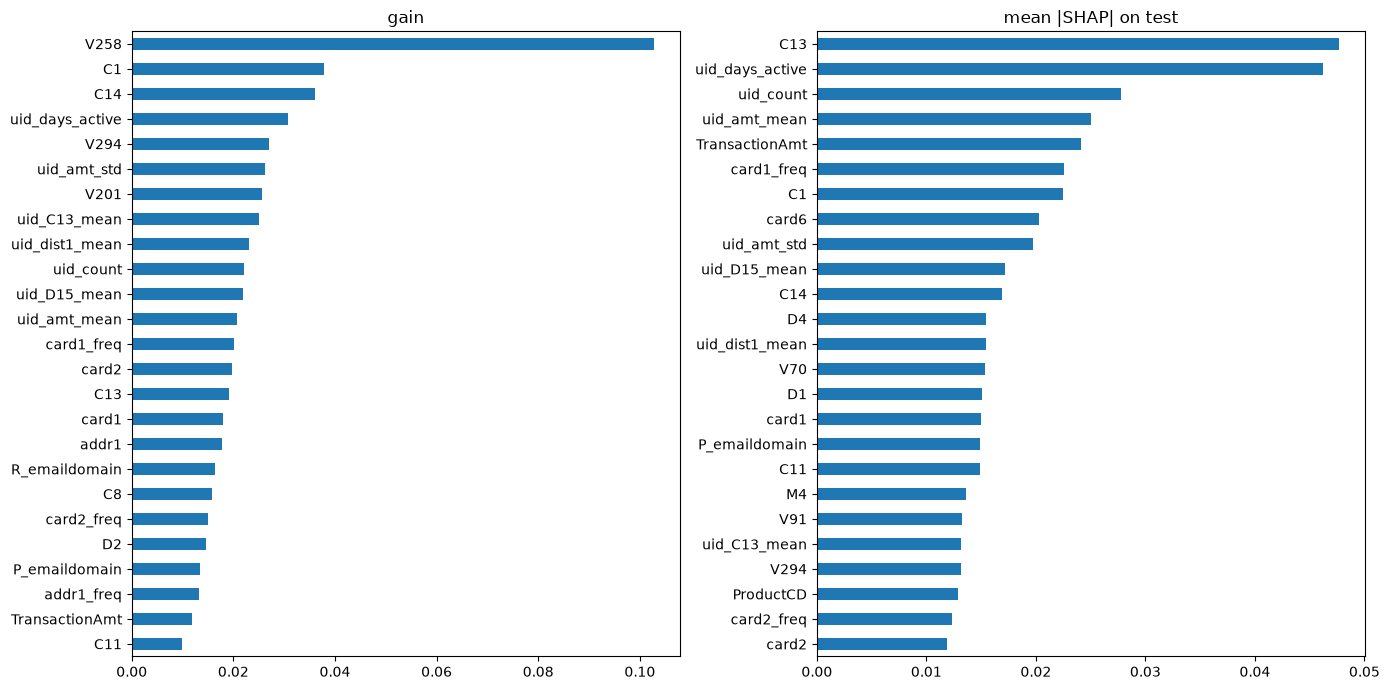

new features: 31 of 460
share of gain: 0.272
share of SHAP: 0.283
in SHAP top 25: 9


In [17]:
final_model = models["lgb_engineered"]
gain = pd.Series(final_model.feature_importance("gain"), index=features)
gain = gain / gain.sum()

shap_rows = rng.choice(test_idx, size=20_000, replace=False)
contrib = final_model.predict(X.loc[shap_rows, features].to_numpy(), pred_contrib=True)
shap = pd.Series(np.abs(contrib[:, :-1]).mean(axis=0), index=features)
shap = shap / shap.sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
gain.nlargest(25)[::-1].plot.barh(ax=axes[0], title="gain")
shap.nlargest(25)[::-1].plot.barh(ax=axes[1], title="mean |SHAP| on test")
plt.tight_layout()
plt.show()

print("new features:", len(new_cols), "of", len(features))
print("share of gain:", round(gain[new_cols].sum(), 3))
print("share of SHAP:", round(shap[new_cols].sum(), 3))
print("in SHAP top 25:", len(set(new_cols) & set(shap.nlargest(25).index)))

The new features are 7% of the columns but give 27% of the gain.

## Is it good enough?

In [18]:
def recall_at_fpr(y_true, score, max_fpr):
    fpr, tpr, _ = roc_curve(y_true, score)
    return tpr[fpr <= max_fpr].max()


def metrics(y_true, score, amt):
    top = np.argsort(-score)[:int(0.01 * len(score))]
    return {
        "ROC-AUC": roc_auc_score(y_true, score),
        "PR-AUC": average_precision_score(y_true, score),
        "Recall @ FPR=1%": recall_at_fpr(y_true, score, 0.01),
        "Precision @ top 1%": y_true[top].mean(),
        "$ recall @ top 1%": (amt[top] * y_true[top]).sum() / (amt * y_true).sum(),
        "log loss": log_loss(y_true, score),
        "mean predicted": score.mean(),
    }


amount = df.loc[train_idx, "TransactionAmt"].to_numpy()
product = df.loc[train_idx, "ProductCD"].to_numpy()

panel = pd.DataFrame({name: metrics(y, p, amount) for name, p in oof_preds.items()})
panel["random"] = metrics(y, rng.uniform(size=len(y)), amount)
print("real fraud rate:", round(y.mean(), 4))
panel.round(4)

real fraud rate: 0.035


,lgb_engineered,lgb_raw,random_forest,random
ROC-AUC,0.9334,0.9073,0.8985,0.4991
PR-AUC,0.6314,0.5556,0.4853,0.0350
Recall @ FPR=1%,0.5438,0.4783,0.3921,0.0103
Precision @ top 1%,0.9355,0.8821,0.8484,0.0359
$ recall @ top 1%,0.1888,0.1717,0.1385,0.0106
log loss,0.0796,0.0907,0.0976,0.9984
mean predicted,0.0287,0.0311,0.0376,0.4996


It catches 54% of fraud at 1% false alarms, but its top 1% has only 19% of the fraud money.

In [19]:
p_oof = oof_preds["lgb_engineered"]

rows = []
for prod in ["W", "C", "R", "H", "S"]:
    m = product == prod
    rows.append({"ProductCD": prod, "rows": m.sum(),
                 "share of fraud": y[m].sum() / y.sum(),
                 "AUC": roc_auc_score(y[m], p_oof[m])})
pd.DataFrame(rows).set_index("ProductCD").round(4)

,rows,share of fraud,AUC
ProductCD,,,
W,439670,0.4341,0.9133
C,68519,0.3876,0.9312
R,37699,0.0690,0.9568
H,33024,0.0762,0.9219
S,11628,0.0332,0.9364


The weakest product is `W`.

## Summary

- The label is basically per client, so client features help the most.
- Removing drifting features doesn't help.
- Tuning helps less than the features.
- CV AUC: 0.935 with my features, 0.911 without, 0.900 random forest.
- Weak spots: product `W` and big frauds.